In [7]:
import pandas as pd
import seaborn as sns
sns.set_palette("pastel")
import plotly.express as px
import matplotlib.pyplot as plt
import math
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
#from xgboost import XGBClassifier
#from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
%matplotlib inline

In [8]:
df = pd.read_csv("data/plasma_lipidomics.csv")

## Data Analysis

In [9]:
df.head()

,Sample,Diagnostic,Sex,Age,MMSE,CSF Amyloid (pg/mL),CSF Total tau (pg/mL),CSF Phosphorylated tau (pg/mL),APOE4,Progression to Alzheimer's Disease,Progression time (months)
0,1,Alzheimer's Disease,Female,68,26,688.0,369.0,107.0,Yes,NaN,NaN
1,2,Alzheimer's Disease,Female,66,22,489.0,482.0,176.0,Yes,NaN,NaN
2,3,Alzheimer's Disease,Female,72,23,509.0,329.0,114.0,Yes,NaN,NaN
3,4,Alzheimer's Disease,Male,73,25,544.0,482.0,80.0,No,NaN,NaN
4,5,Alzheimer's Disease,Female,75,15,303.0,806.0,120.0,No,NaN,NaN


In [10]:
len(df)

212

In [11]:
def histogram(label,rotation=None):
    ax = sns.histplot(data=df,x=label,hue=label,legend=False, shrink=.9)
    if rotation:
        ax.tick_params(axis='x', labelrotation=rotation)
    # Add the counts on top of each bar automatically
    for container in ax.containers:
        ax.bar_label(container, fmt=lambda x: str(int(x)) if x > 0 else '')
    image_title = label.replace(" ", "_")
    plt.savefig(image_title, dpi=300, bbox_inches="tight")
    plt.show()

In [12]:
def histogram_totals(totals,title,xlabel):
    labels = ['Yes', 'No']   
    # 2. Create the bar plot
    plt.figure(figsize=(6, 4))
    ax = sns.barplot(x=labels, y=totals, palette=['#a1c9f4', '#ffb482'])
    for container in ax.containers:
            ax.bar_label(container, fmt=lambda x: str(int(x)) if x > 0 else '')
    # 3. Add labels and show
    plt.title(title)
    image_title = title.replace(" ", "_")
    plt.savefig(image_title, dpi=300, bbox_inches="tight")
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.show()

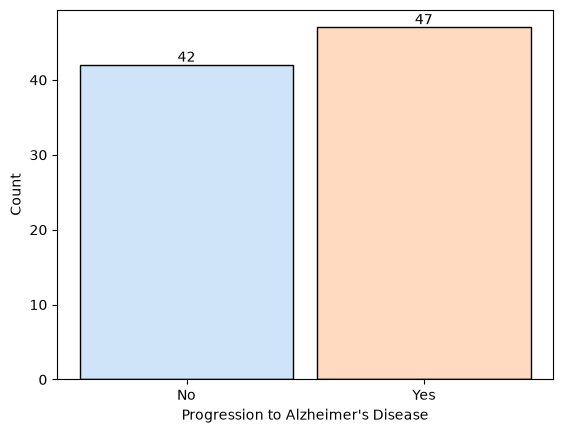

In [13]:
histogram("Progression to Alzheimer's Disease")

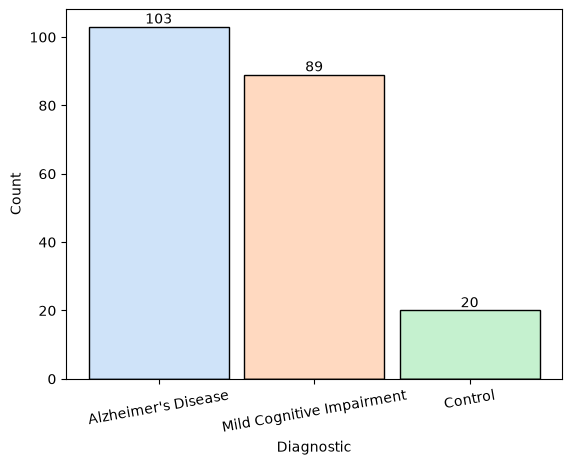

In [14]:
histogram("Diagnostic",rotation=10)

Exploring the relationships between Diagnostic and the key indicator "Progression to Alzeimers's Disease". 

In [15]:
#APOE4, CSF Phosphorylated tau (pg/mL), CSF Total tau (pg/mL), CSF Amyloid (pg/mL)

In [16]:
overlap_yes = df[(df['Diagnostic'] == 'Mild Cognitive Impairment') & (df["Progression to Alzheimer's Disease"] == 'Yes')]
overlap_no  = df[(df['Diagnostic'] == 'Mild Cognitive Impairment') & (df["Progression to Alzheimer's Disease"] == 'No')]

print("Non-MCI patients with Progression = Yes:", len(overlap_yes))
print("Non-MCI patients with Progression = No:", len(overlap_no))

Non-MCI patients with Progression = Yes: 47
Non-MCI patients with Progression = No: 42


In [17]:
totals =[len(overlap_yes), len(overlap_no)]
totals

[47, 42]

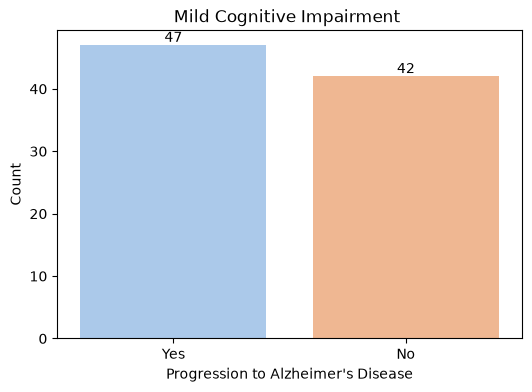

In [18]:
histogram_totals(totals=totals, title="Mild Cognitive Impairment ",xlabel="Progression to Alzheimer's Disease")

In [19]:
overlap_yes = df[(df['Diagnostic'] == "Alzheimer's Disease") & (df["Progression to Alzheimer's Disease"] == 'Yes')]
overlap_no  = df[(df['Diagnostic'] == "Alzheimer's Disease") & (df["Progression to Alzheimer's Disease"] == 'No')]

print("Non-MCI patients with Progression = Yes:", len(overlap_yes))
print("Non-MCI patients with Progression = No:", len(overlap_no))


Non-MCI patients with Progression = Yes: 0
Non-MCI patients with Progression = No: 0


In [20]:
df[df['Diagnostic'] == "Alzheimer's Disease"]

,Sample,Diagnostic,Sex,Age,MMSE,CSF Amyloid (pg/mL),CSF Total tau (pg/mL),CSF Phosphorylated tau (pg/mL),APOE4,Progression to Alzheimer's Disease,Progression time (months)
0,1,Alzheimer's Disease,Female,68,26,688.0,369.0,107.0,Yes,NaN,NaN
1,2,Alzheimer's Disease,Female,66,22,489.0,482.0,176.0,Yes,NaN,NaN
2,3,Alzheimer's Disease,Female,72,23,509.0,329.0,114.0,Yes,NaN,NaN
3,4,Alzheimer's Disease,Male,73,25,544.0,482.0,80.0,No,NaN,NaN
4,5,Alzheimer's Disease,Female,75,15,303.0,806.0,120.0,No,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
99,100,Alzheimer's Disease,Female,79,19,395.0,377.0,54.8,No,NaN,NaN
100,101,Alzheimer's Disease,Female,71,28,556.0,257.0,48.1,Yes,NaN,NaN
101,102,Alzheimer's Disease,Female,70,25,354.0,312.0,53.8,Yes,NaN,NaN
102,103,Alzheimer's Disease,Male,79,25,755.0,685.0,86.3,No,NaN,NaN


In [21]:
overlap_yes = df[(df['Diagnostic'] == "Control") & (df["Progression to Alzheimer's Disease"] == 'Yes')]
overlap_no  = df[(df['Diagnostic'] == "Control") & (df["Progression to Alzheimer's Disease"] == 'No')]

print("Non-MCI patients with Progression = Yes:", len(overlap_yes))
print("Non-MCI patients with Progression = No:", len(overlap_no))

Non-MCI patients with Progression = Yes: 0
Non-MCI patients with Progression = No: 0


There are no patients who's diagnostic is 'Alzheimer's Disease' or 'Control' "Progression to Alzheimer's Disease"

Therefore are two we will only consider are "Mild Cognitive Impairment" and "Progression to Alzheimer's Disease" Yes or No

We are going to look at the Mayo Clinic's hypothesis, and APOE4, CSF Phosphorylated tau (pg/mL), CSF Total tau (pg/mL), CSF Amyloid (pg/mL)

Test each value with the same metric - StandardScaler/LogistitRegression, and once the best parameters are determined, we pick the best classifier method.

In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score

We have a problem, some of the Mild Cognitive Impairments have Nan APOE4 values.
So we are going to replace the Nan values with the most common APOE4 value or mode which is 'No'
Then we covert the APOE4 and Progression to Alzheimer's Disease Yes/No to 1/0

# APOE4

In [ ]:
# Isolate the 'Mild Cognitive Impairment' set
mci = df[df['Diagnostic'] == 'Mild Cognitive Impairment'].copy() 
# Determine the mode
apoe4_mode = mci['APOE4'].mode()[0]
# Fill all Nan value with 'No'
mci['APOE4'] = mci['APOE4'].fillna(apoe4_mode)
# Convert Yes/No to 1/0
mci['APOE4_bin'] = (mci['APOE4'] == 'Yes').astype(int)

# Create the target
mci['target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
y = mci['target']
# X is APOE4
X = mci[['APOE4_bin']]


In [ ]:

def evaluate_performance(terms, X,y):
    # ---- 5-fold cross-validation, honest out-of-fold predictions ----
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    model = Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))])
    
    y_pred = cross_val_predict(model, X, y, cv=cv, method='predict')
    y_proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]
    
    # ---- Confusion matrix ----
    terms = ' '.join(terms)
    print(f"Predicing 'Progression to Alzheimer's Disease' from {terms}\n")
    cm = confusion_matrix(y, y_pred, labels=[0, 1])
    print(pd.DataFrame(cm, index=['Actual: No', 'Actual: Yes'], columns=['Pred: No', 'Pred: Yes']))
    
    # ---- Precision, recall, F1, accuracy, AUC ----
    print(classification_report(y, y_pred, target_names=['No progression', 'Progressed'], digits=3))
    print('Accuracy:', accuracy_score(y, y_pred))
    print('AUC:', roc_auc_score(y, y_proba))

In [ ]:
evaluate_performance(['APOE4'],X,y)

## 'CSF Amyloid (pg/mL)'

In [ ]:
df = pd.read_csv("data/plasma_lipidomics.csv")
mci = df[df['Diagnostic'] == 'Mild Cognitive Impairment'].copy() 
amyloid_median = mci['CSF Amyloid (pg/mL)'].median()
mci['CSF Amyloid (pg/mL)'] = mci['CSF Amyloid (pg/mL)'].fillna(amyloid_median)


mci['target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
y = mci['target']
X = mci[['CSF Amyloid (pg/mL)']]


In [ ]:
evaluate_performance(['CSF Amyloid (pg/mL)'],X,y)

## CSF Total tau (pg/mL)'

In [ ]:
parameter = 'CSF Total tau (pg/mL)'
df = pd.read_csv("data/plasma_lipidomics.csv")
mci = df[df['Diagnostic'] == 'Mild Cognitive Impairment'].copy() 
tau_median = mci['CSF Total tau (pg/mL)'].median()
mci['CSF Total tau (pg/mL)'] = mci['CSF Total tau (pg/mL)'].fillna(tau_median)


mci['target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
y = mci['target']
X = mci[['CSF Total tau (pg/mL)']]


In [ ]:
evaluate_performance([parameter],X,y)

## Tau

In [ ]:

df = pd.read_csv("data/plasma_lipidomics.csv")
mci = df[df['Diagnostic'] == 'Mild Cognitive Impairment'].copy() 

amyloid_median = mci['CSF Phosphorylated tau (pg/mL)'].median()
mci['CSF Phosphorylated tau (pg/mL)'] = mci['CSF Phosphorylated tau (pg/mL)'].fillna(amyloid_median)

mci['target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
y = mci['target']
X = mci[['CSF Phosphorylated tau (pg/mL)']]


In [ ]:
evaluate_performance(['CSF Phosphorylated tau (pg/mL)'],X,y)

## Tau and Total Tau

In [ ]:
df = pd.read_csv("data/plasma_lipidomics.csv")
mci = df[df['Diagnostic'] == 'Mild Cognitive Impairment'].copy() 

amyloid_median = mci['CSF Phosphorylated tau (pg/mL)'].median()
mci['CSF Phosphorylated tau (pg/mL)'] = mci['CSF Phosphorylated tau (pg/mL)'].fillna(amyloid_median)

amyloid_median = mci['CSF Total tau (pg/mL)'].median()
mci['CSF Total tau (pg/mL)'] = mci['CSF Total tau (pg/mL)'].fillna(amyloid_median)

mci['target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
y = mci['target']
X = mci[['CSF Phosphorylated tau (pg/mL)', 'CSF Total tau (pg/mL)']]

In [ ]:
evaluate_performance(['CSF Phosphorylated tau (pg/mL)', 'CSF Total tau (pg/mL)'],X,y)

### Tau just above random, Total Tau alone is better

## AmyLoid and Total Tau

In [ ]:
df = pd.read_csv("data/plasma_lipidomics.csv")
mci = df[df['Diagnostic'] == 'Mild Cognitive Impairment'].copy() 
amyloid_median = mci['CSF Amyloid (pg/mL)'].median()
mci['CSF Amyloid (pg/mL)'] = mci['CSF Amyloid (pg/mL)'].fillna(amyloid_median)

tau_median = mci['CSF Total tau (pg/mL)'].median()
mci['CSF Total tau (pg/mL)'] = mci['CSF Total tau (pg/mL)'].fillna(tau_median)

mci['target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
y = mci['target']
X = mci[['CSF Amyloid (pg/mL)','CSF Total tau (pg/mL)']]

In [ ]:
evaluate_performance(['CSF Amyloid (pg/mL)','CSF Total tau (pg/mL)'],X,y)

**'CSF Amyloid (pg/mL)' and'CSF Total tau (pg/mL)' has the best accuracy**

### Given 'CSF Amyloid (pg/mL)' and'CSF Total tau (pg/mL)', what's the best classification algorithm?

In [ ]:
import pandas as pd, numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

def evaluate_pipelines(X,y,model):
    # ---- 5-fold cross-validation, honest out-of-fold predictions ----
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    y_pred = cross_val_predict(model[1], X, y, cv=cv, method='predict')
    y_proba = cross_val_predict(model[1], X, y, cv=cv, method='predict_proba')[:, 1]
    
    # ---- Confusion matrix ----
    terms = ' '.join(['CSF Amyloid (pg/mL)','CSF Total tau (pg/mL)'])
    print(f"Predicing 'Progression to Alzheimer's Disease' from {terms} with {model[0]} classifier" )

    cm = confusion_matrix(y, y_pred, labels=[0, 1])
    print(pd.DataFrame(cm, index=['Actual: No', 'Actual: Yes'], columns=['Pred: No', 'Pred: Yes']))
    
    # ---- Precision, recall, F1, accuracy, AUC ----
    print(classification_report(y, y_pred, target_names=['No progression', 'Progressed'], digits=3))
    print('Accuracy:', accuracy_score(y, y_pred))
    print('AUC:', roc_auc_score(y, y_proba))
    print('Recall (Progressed):', recall_score(y, y_pred))   # <-- new line

In [ ]:
models = {
    'Logistic Regression': Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))]),
    'Random Forest':        RandomForestClassifier(n_estimators=300, random_state=42),
    'SVM (RBF)':            Pipeline([('sc', StandardScaler()), ('clf', SVC(probability=True, random_state=42))]),
    'Gradient Boosting':    GradientBoostingClassifier(random_state=42),
    'K-Nearest Neighbors':  Pipeline([('sc', StandardScaler()), ('clf', KNeighborsClassifier())]),
    'LDA':                  Pipeline([('sc', StandardScaler()), ('clf', LinearDiscriminantAnalysis())]),
    'Naive Bayes':          Pipeline([('sc', StandardScaler()), ('clf', GaussianNB())]),
}
for model in models.items():
    print(model[0])
    evaluate_pipelines(X,y,model)

## Null Hyphothesis

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, permutation_test_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ---- Build mci and the two-feature X, y (same as before) ----
df = pd.read_csv("data/plasma_lipidomics.csv")
cols = ['CSF Amyloid (pg/mL)', 'CSF Total tau (pg/mL)']
for col in cols:
    df[col] = df.groupby('Diagnostic')[col].transform(lambda s: s.fillna(s.median()))

mci = df[df.Diagnostic == 'Mild Cognitive Impairment'].copy()
mci['target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
y = mci['target']
X = mci[cols]

# ---- Run the permutation test: 1000 shuffles of y, refit each time ----
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))])

score, perm_scores, pvalue = permutation_test_score(
    model, X, y, cv=cv, scoring='roc_auc',
    n_permutations=1000, random_state=42, n_jobs=-1
)

print('Observed AUC:', score)
print('sklearn p-value:', pvalue)

# ---- Manually verify how that p-value is actually computed ----

# Step 1: count how many of the 1000 shuffled AUCs are >= the real AUC
count_as_extreme = np.sum(perm_scores >= score)
print('Count of shuffles at least as extreme:', count_as_extreme)

# Step 2: the naive version -- just divide by the number of permutations
naive_p = count_as_extreme / len(perm_scores)
print('Naive p-value:', naive_p)

# Step 3: the actual formula -- add 1 to numerator AND denominator
corrected_p = (count_as_extreme + 1) / (len(perm_scores) + 1)
print('Corrected p-value:', corrected_p)

You've now got a fully verified, end-to-end statistical result: 0 out of 1000 random shuffles beat the real AUC of 0.81, giving p ≈ 0.001 — well below the standard 0.05 significance threshold. 

Combined with everything else you've built up (biomarker distributions moving in the expected direction, multiple algorithms agreeing, Age/Sex showing no signal as a control), that's a solid, defensible case for the Mayo Clinic hypothesis on this dataset.